In [18]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier, Pool, cv
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import numpy as np
import pandas as pd
from typing import Dict, List, Tuple, Optional, Any
from dataclasses import dataclass
from pathlib import Path

import sys
sys.path.append('..')
from utils.extract_features import extract_features

In [19]:
# Стандартные тестовые примеры
TEST_CASES = [
    ("<script>alert('XSS')</script>", True),
    ("<div>Hello World</div>", False),
    ("<img src=x onerror=alert(1)>", True),
    ("<p>Normal paragraph</p>", False),
    ("<svg onload=alert(document.cookie)>", True),
    ("<a href='/about'>About</a>", False),
]

ADDITIONAL_TEST_CASES = [
    ("<div class='test'>Hello</div>", False),
    ("<script>alert('hacked')</script>", True),
    ("<img src='x' onerror='javascript:alert(1)'>", True),
    ("%3Cscript%3Ealert('xss')%3C/script%3E", True),
]

In [20]:
@dataclass
class ModelConfig:
    """Конфигурация модели CatBoost"""
    model_dir: Path = Path("./")
    model_filename: str = "catboost_xss_model.cbm"
    metadata_filename: str = "model_metadata.pkl"
    scaler_filename: str = "scaler.pkl"
    
    iterations: int = 10000
    depth: int = 6
    learning_rate: float = 0.05
    loss_function: str = "Logloss"
    eval_metric: str = "AUC"
    early_stopping_rounds: int = 50
    bootstrap_type: str = "Bernoulli"
    subsample: float = 0.8
    l2_leaf_reg: int = 3
    random_seed: int = 42
    task_type: str = "CPU"
    
    js_weight: float = 1.0
    html_weight: float = 0.7
    default_weight: float = 0.5
    
    default_threshold: float = 0.5
    test_threshold: float = 0.35
    test_size: float = 0.2
    
    def __post_init__(self):
        self.model_dir.mkdir(exist_ok=True)
    
    @property
    def model_path(self) -> Path:
        return self.model_dir / self.model_filename
    
    @property
    def metadata_path(self) -> Path:
        return self.model_dir / self.metadata_filename
    
    def get_model_params(self) -> dict:
        return {
            'iterations': self.iterations,
            'depth': self.depth,
            'learning_rate': self.learning_rate,
            'loss_function': self.loss_function,
            'verbose': 100,
            'random_seed': self.random_seed,
            'task_type': self.task_type,
            'eval_metric': self.eval_metric,
            'early_stopping_rounds': self.early_stopping_rounds,
            'use_best_model': True,
            'bootstrap_type': self.bootstrap_type,
            'subsample': self.subsample,
            'l2_leaf_reg': self.l2_leaf_reg,
            'metric_period': 50,
            'devices': '0'
        }


@dataclass
class DataConfig:
    train_filename: str = "../datasets_train/xss_dataset.csv"
    test_filename: str = "../datasets_test/xss_dataset.csv"
    encoding: str = "utf-8"
    text_column: str = "text"
    label_column: str = "label"
    batch_size: int = 500

In [21]:
class BaseXSSTester:
    """Базовый класс для детектирования XSS"""
    
    def __init__(self):
        self.model: Optional[CatBoostClassifier] = None
        self.metadata: Optional[Dict] = None
    
    def load_model(self) -> None:
        """Загружает модель – должен быть переопределён в наследнике"""
        raise NotImplementedError
    
    def prepare_features(self, features_dict: Dict) -> pd.DataFrame:
        if self.metadata is None:
            raise ValueError("Метаданные не загружены!")
        
        features_df = pd.DataFrame([features_dict])
        expected_features = self.metadata['feature_names']
        for feature in expected_features:
            if feature not in features_df.columns:
                features_df[feature] = 0
        features_df = features_df[expected_features]
        
        cat_features = self.metadata.get('cat_features', [])
        for col in cat_features:
            if col in features_df.columns:
                features_df[col] = features_df[col].astype('category')
        return features_df
    
    def _predict_proba(self, features_df: pd.DataFrame) -> Tuple[int, float]:
        if self.model is None:
            raise ValueError("Модель не загружена!")
        pred = self.model.predict(features_df)[0]
        proba = self.model.predict_proba(features_df)[0][1]
        return pred, proba
    
    def _get_risk_level(self, prob: float) -> str:
        if prob >= 0.8: return "CRITICAL"
        if prob >= 0.6: return "HIGH"
        if prob >= 0.4: return "MEDIUM"
        if prob >= 0.2: return "LOW"
        return "SAFE"
    
    def _get_top_features(self, features_df: pd.DataFrame) -> list:
        if self.model is None or self.metadata is None:
            return []
        try:
            shap = self.model.get_feature_importance(data=features_df, type='PredictionValuesChange')
            names = self.metadata['feature_names']
            top = []
            for idx in np.argsort(shap)[-5:][::-1]:
                if shap[idx] > 0:
                    top.append(f"{names[idx]}={features_df.iloc[0, idx]}")
            return top
        except:
            return []
    
    def predict_single(self, code: str, threshold: float = 0.5) -> Dict:
        features = extract_features(code)
        features_df = self.prepare_features(features)
        pred, proba = self._predict_proba(features_df)
        is_xss = proba >= threshold
        return {
            'is_xss': bool(is_xss),
            'probability': float(proba),
            'prediction': pred,
            'code_sample': code[:100] + '...' if len(code) > 100 else code,
            'risk_level': self._get_risk_level(proba),
            'features': self._get_top_features(features_df)
        }
    
    def predict_batch(self, codes: List[str], threshold: float = 0.5) -> pd.DataFrame:
        return pd.DataFrame([self.predict_single(c, threshold) for c in codes]) 

In [22]:
class XSSLearnDetector(BaseXSSTester):
    def __init__(self, config: Optional[ModelConfig] = None):
        super().__init__()
        self.config = config or ModelConfig()
        self.stats = {'total_predictions': 0, 'xss_detected': 0,
                      'false_positives': 0, 'false_negatives': 0}
        if self.config.model_path.exists():
            self.load_model()
    
    def load_model(self) -> None:
        self.model = CatBoostClassifier()
        self.model.load_model(str(self.config.model_path))
        self.metadata = joblib.load(self.config.metadata_path)
        print(f"📤 Модель загружена из {self.config.model_path}")
    
    def save_model(self, model: CatBoostClassifier, feature_names: list, cat_features: list):
        model.save_model(str(self.config.model_path))
        metadata = {'feature_names': list(feature_names), 'cat_features': cat_features,
                    'model_type': 'CatBoost', 'version': '1.0'}
        joblib.dump(metadata, self.config.metadata_path)
        print(f"💾 Модель сохранена в {self.config.model_path}")
        return self.config.model_path, self.config.metadata_path
    
    def predict(self, code: str, threshold: float = None) -> Dict:
        threshold = threshold or self.config.default_threshold
        self.stats['total_predictions'] += 1
        result = self.predict_single(code, threshold)
        if result['is_xss']:
            self.stats['xss_detected'] += 1
        return result
    
    def evaluate_on_dataset(self, test_csv: str, threshold: float = None) -> Dict:
        threshold = threshold or self.config.test_threshold
        df = pd.read_csv(test_csv)
        y_true, y_pred, y_proba = [], [], []
        for text in df['text']:
            res = self.predict(text, threshold)
            y_true.append(1 if res['is_xss'] else 0)
            y_pred.append(res['is_xss'])
            y_proba.append(res['probability'])
        cm = confusion_matrix(y_true, y_pred)
        self.stats['false_positives'] += cm[0,1]
        self.stats['false_negatives'] += cm[1,0]
        print(classification_report(y_true, y_pred))
        print(f"AUC: {roc_auc_score(y_true, y_proba):.4f}")
        return classification_report(y_true, y_pred, output_dict=True)
    
    def get_stats(self) -> Dict:
        return self.stats.copy()

In [23]:
def load_and_prepare_data(csv_file: str, with_label: bool = True, 
                          data_cfg: DataConfig = None) -> Tuple[pd.DataFrame, Optional[np.ndarray]]:
    cfg = data_cfg or DataConfig()
    df = pd.read_csv(csv_file)
    features = []
    for i, text in enumerate(df[cfg.text_column]):
        if i % cfg.batch_size == 0:
            print(f"Обработано {i}/{len(df)}")
        features.append(extract_features(text))
    X = pd.DataFrame(features)
    y = df[cfg.label_column].values if with_label else None
    print(f"✅ {X.shape[0]} примеров, {X.shape[1]} признаков")
    if with_label:
        print(f"📊 XSS: {y.sum()}, нормальных: {len(y)-y.sum()}")
    return X, y

def get_categorical_features(X: pd.DataFrame) -> List[str]:
    cat = [col for col in X.columns 
           if X[col].nunique() <= 8 and set(X[col].unique()).issubset({0,1})]
    print(f"🎯 Категориальных признаков: {len(cat)}")
    return cat

def get_feature_weights(cat_features: List[str], cfg: ModelConfig) -> List[float]:
    return [cfg.js_weight if 'js' in f else cfg.html_weight if 'html' in f else cfg.default_weight 
            for f in cat_features]

def train_with_cv(X: pd.DataFrame, y: np.ndarray, cat_features: List[str], cfg: ModelConfig):
    pool = Pool(X, y, cat_features=cat_features, text_features=['text'])
    params = cfg.get_model_params()
    cv_data = cv(pool, params, fold_count=5, shuffle=True, 
                 partition_random_seed=cfg.random_seed, stratified=True, plot=True)
    print(f"Среднее AUC: {cv_data['test-AUC-mean'].mean():.4f} ± {cv_data['test-AUC-std'].mean():.4f}")
    return cv_data, params

def train_final_model(X, y, cat_features, params, cfg: ModelConfig):
    X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=cfg.test_size, 
                                                random_state=cfg.random_seed, stratify=y)
    train_pool = Pool(X_tr, y_tr, cat_features=cat_features, text_features=['text'])
    val_pool = Pool(X_val, y_val, cat_features=cat_features, text_features=['text'])
    model = CatBoostClassifier(**params)
    model.fit(train_pool, eval_set=val_pool, verbose=100, plot=True)
    
    y_pred = model.predict(X_val)
    print(classification_report(y_val, y_pred))
    print(f"AUC: {roc_auc_score(y_val, model.predict_proba(X_val)[:,1]):.4f}")
    
    # Матрица ошибок
    sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title('Матрица ошибок (обучение)')
    plt.savefig('confusion_matrix.png')
    plt.show()
    return model

def analyze_feature_importance(model, X):
    importance = model.get_feature_importance()
    imp_df = pd.DataFrame({'feature': X.columns, 'importance': importance})\
               .sort_values('importance', ascending=False).head(5)
    plt.figure(figsize=(12,5))
    plt.barh(imp_df['feature'], imp_df['importance'])
    plt.gca().invert_yaxis()
    plt.title('Топ-5 важных признаков')
    plt.tight_layout()
    plt.savefig('features.png')
    plt.show()
    return imp_df

ОБУЧЕНИЕ МОДЕЛИ DETECT XSS
Обработано 0/13226
Обработано 500/13226
Обработано 1000/13226
Обработано 1500/13226
Обработано 2000/13226
Обработано 2500/13226
Обработано 3000/13226
Обработано 3500/13226
Обработано 4000/13226
Обработано 4500/13226
Обработано 5000/13226
Обработано 5500/13226
Обработано 6000/13226
Обработано 6500/13226
Обработано 7000/13226
Обработано 7500/13226
Обработано 8000/13226
Обработано 8500/13226
Обработано 9000/13226
Обработано 9500/13226
Обработано 10000/13226
Обработано 10500/13226
Обработано 11000/13226
Обработано 11500/13226
Обработано 12000/13226
Обработано 12500/13226
Обработано 13000/13226
✅ 13226 примеров, 81 признаков
📊 XSS: 6613, нормальных: 6613
🎯 Категориальных признаков: 37


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Training on fold [0/5]
0:	test: 0.9992441	best: 0.9992441 (0)	total: 21.9ms	remaining: 3m 39s

bestTest = 1
bestIteration = 4

Training on fold [1/5]
0:	test: 0.9988662	best: 0.9988662 (0)	total: 27.9ms	remaining: 4m 38s

bestTest = 1
bestIteration = 8

Training on fold [2/5]
0:	test: 0.9852608	best: 0.9852608 (0)	total: 17.9ms	remaining: 2m 58s

bestTest = 1
bestIteration = 1

Training on fold [3/5]
0:	test: 1.0000000	best: 1.0000000 (0)	total: 18.9ms	remaining: 3m 8s

bestTest = 1
bestIteration = 0

Training on fold [4/5]
0:	test: 0.9860061	best: 0.9860061 (0)	total: 28.6ms	remaining: 4m 46s

bestTest = 1
bestIteration = 3

Среднее AUC: 0.9980 ± 0.0025


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	test: 0.9996221	best: 0.9996221 (0)	total: 20.9ms	remaining: 3m 28s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1
bestIteration = 1

Shrink model to first 2 iterations.
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1323
           1       1.00      0.98      0.99      1323

    accuracy                           0.99      2646
   macro avg       0.99      0.99      0.99      2646
weighted avg       0.99      0.99      0.99      2646

AUC: 1.0000


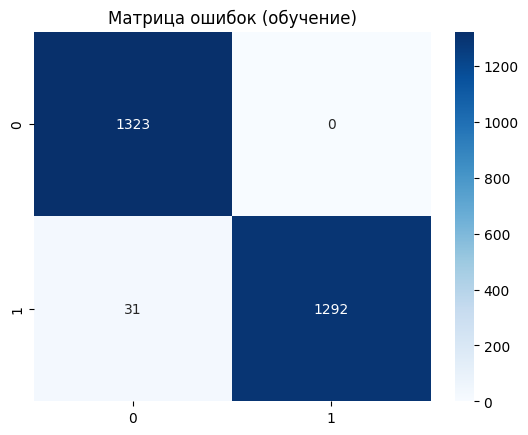

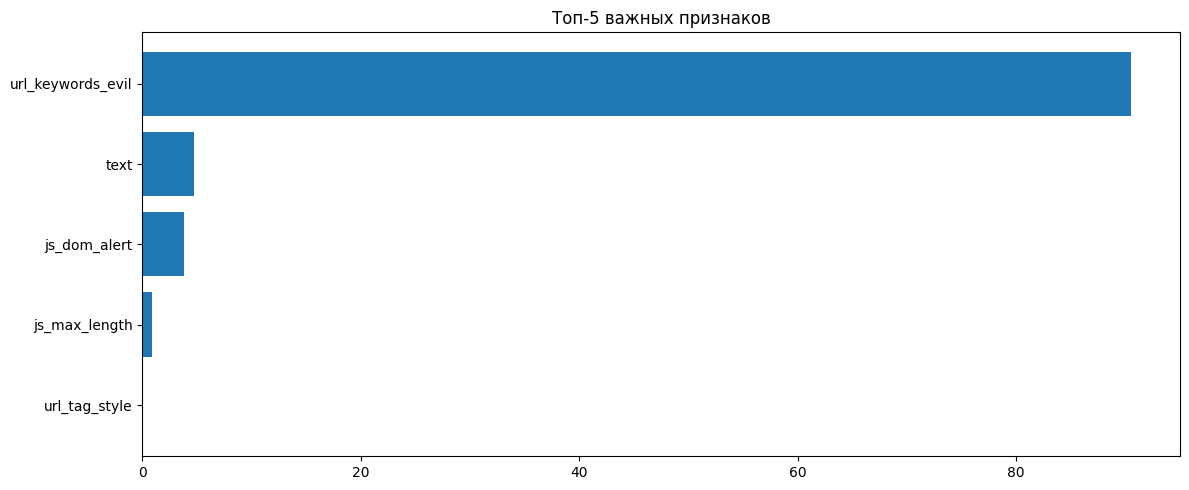

📤 Модель загружена из catboost_xss_model.cbm
💾 Модель сохранена в catboost_xss_model.cbm

🧪 Тестирование на примерах:

📝 <script>alert('XSS')</script>
   XSS: True | Вероятность: 99.91% | Риск: CRITICAL

📝 <div>Hello World</div>
   XSS: False | Вероятность: 15.63% | Риск: SAFE

📝 <img src=x onerror=alert(1)>
   XSS: True | Вероятность: 99.97% | Риск: CRITICAL

📝 <p>Normal paragraph</p>
   XSS: False | Вероятность: 15.63% | Риск: SAFE

📝 <svg onload=alert(document.cookie)>
   XSS: True | Вероятность: 99.96% | Риск: CRITICAL

📝 <a href='/about'>About</a>
   XSS: False | Вероятность: 0.47% | Риск: SAFE

ОЦЕНКА НА ТЕСТОВОМ ДАТАСЕТЕ
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6104
           1       1.00      1.00      1.00      7122

    accuracy                           1.00     13226
   macro avg       1.00      1.00      1.00     13226
weighted avg       1.00      1.00      1.00     13226

AUC: 1.0000

✅ РАБОТА ЗАВЕРШЕНА


In [24]:
# ========== НАСТРОЙКА ==========
model_cfg = ModelConfig()
data_cfg = DataConfig()

# ========== ЗАГРУЗКА И ПОДГОТОВКА ==========
print("="*60)
print("ОБУЧЕНИЕ МОДЕЛИ DETECT XSS")
print("="*60)

X, y = load_and_prepare_data(data_cfg.train_filename, data_cfg)
cat_features = get_categorical_features(X)

# ========== КРОСС-ВАЛИДАЦИЯ ==========
cv_results, best_params = train_with_cv(X, y, cat_features, model_cfg)

# ========== ДОБАВЛЯЕМ ВЕСА ПРИЗНАКОВ ==========
best_params['feature_weights'] = get_feature_weights(cat_features, model_cfg)

# ========== ФИНАЛЬНОЕ ОБУЧЕНИЕ ==========
model = train_final_model(X, y, cat_features, best_params, model_cfg)

# ========== АНАЛИЗ ВАЖНОСТИ ==========
importance = analyze_feature_importance(model, X)

# ========== СОХРАНЕНИЕ ==========
detector = XSSLearnDetector(model_cfg)
detector.save_model(model, X.columns, cat_features)

# ========== ТЕСТИРОВАНИЕ НА ПРИМЕРАХ ==========
print("\n🧪 Тестирование на примерах:")
for code, _ in TEST_CASES:
    res = detector.predict_single(code, threshold=0.5)
    print(f"\n📝 {res['code_sample']}")
    print(f"   XSS: {res['is_xss']} | Вероятность: {res['probability']:.2%} | Риск: {res['risk_level']}")
    if res['features']:
        print(f"   Причины: {', '.join(res['features'])}")

# ========== ОЦЕНКА НА ТЕСТОВОМ ДАТАСЕТЕ ==========
print("\n" + "="*60)
print("ОЦЕНКА НА ТЕСТОВОМ ДАТАСЕТЕ")
print("="*60)
detector.evaluate_on_dataset(data_cfg.test_filename, threshold=model_cfg.test_threshold)

print("\n✅ РАБОТА ЗАВЕРШЕНА")

In [25]:
test_detector = XSSLearnDetector(model_cfg)

print("\n🧪 Дополнительные тесты:")
for code, expected in ADDITIONAL_TEST_CASES:
    res = test_detector.predict_single(code, threshold=0.35)
    print(f"\n📝 {res['code_sample']}")
    print(f"   XSS: {res['is_xss']} (ожидалось: {expected}) | Вероятность: {res['probability']:.2%}")

📤 Модель загружена из catboost_xss_model.cbm

🧪 Дополнительные тесты:

📝 <div class='test'>Hello</div>
   XSS: True (ожидалось: False) | Вероятность: 49.36%

📝 <script>alert('hacked')</script>
   XSS: True (ожидалось: True) | Вероятность: 69.79%

📝 <img src='x' onerror='javascript:alert(1)'>
   XSS: True (ожидалось: True) | Вероятность: 64.24%

📝 %3Cscript%3Ealert('xss')%3C/script%3E
   XSS: True (ожидалось: True) | Вероятность: 69.79%
